In [2]:
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path
from PIL import Image
from tqdm.auto import tqdm
import hashlib
import requests
import pandas as pd
import torch

def make_image_filename(row) -> str:
    raw = f"{row['post_key']}_{row['url']}"
    file_hash = hashlib.md5(raw.encode("utf-8")).hexdigest()[:12]
    return f"{row['post_key']}_{file_hash}.jpg"


def is_valid_image(path: Path) -> bool:
    try:
        with Image.open(path) as img:
            img.verify()
        return True
    except Exception:
        return False


def download_one_row(row, out_dir="vk_images", timeout=20):
    out_path = Path(out_dir)
    out_path.mkdir(parents=True, exist_ok=True)

    filename = make_image_filename(row)
    save_path = out_path / filename

    try:
        if save_path.exists():
            if is_valid_image(save_path):
                return str(row["post_key"]), str(save_path), 1
            try:
                save_path.unlink()
            except Exception:
                pass

        with requests.get(row["url"], timeout=timeout, stream=True) as resp:
            resp.raise_for_status()
            with open(save_path, "wb") as f:
                for chunk in resp.iter_content(8192):
                    if chunk:
                        f.write(chunk)

        if not is_valid_image(save_path):
            try:
                save_path.unlink()
            except Exception:
                pass
            return str(row["post_key"]), None, 0

        return str(row["post_key"]), str(save_path), 1

    except Exception:
        if save_path.exists():
            try:
                save_path.unlink()
            except Exception:
                pass
        return str(row["post_key"]), None, 0


def download_images_parallel(photos_df, out_dir="vk_images", max_workers=16):
    df = photos_df.copy().reset_index(drop=True)

    df["image_key"] = df["post_key"].astype(str)

    image_path_map = {}
    ok_map = {}

    rows = [row for _, row in df.iterrows()]

    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        futures = [ex.submit(download_one_row, row, out_dir) for row in rows]

        for fut in tqdm(as_completed(futures), total=len(futures), desc="Downloading images"):
            image_key, image_path, ok = fut.result()
            image_path_map[image_key] = image_path
            ok_map[image_key] = ok

    df["image_path"] = df["image_key"].map(image_path_map)
    df["download_ok"] = df["image_key"].map(ok_map)

    return df

In [3]:
photos = pd.read_csv("photos_vk.csv")

In [5]:
photos_local = download_images_parallel(
    photos,
    out_dir="vk_images",
    max_workers=24

)

In [98]:
photos_local.to_csv("photos_vk_with_local_paths.csv", index=False)

In [6]:
photos_local = photos_local[
    (photos_local["download_ok"] == 1) &
    (photos_local["image_path"].notna())
].reset_index(drop=True)

In [8]:
posts_all = pd.read_csv("posts_vk.csv")

In [9]:
posts_all.head()

,domain,owner_id,post_id,post_key,from_id,dt_msk,edited_dt_msk,text,views,likes,...,reactions_total,is_pinned,marked_as_ads,is_donut,post_source_type,post_type,n_photos,cover_photo_url,all_photo_urls,post_url
0,literabook,-33874468,953135,-33874468_953135,-33874468,2026-04-02 11:33:58+03:00,NaN,"Интимнее, чем секс \nВсякий раз, когда мы гово...",31453,66,...,66.0,0,0,0,api,post,1,https://sun9-26.userapi.com/s/v1/ig2/N24sE2iTm...,"[""https://sun9-26.userapi.com/s/v1/ig2/N24sE2i...",https://vk.com/wall-33874468_953135
1,literabook,-33874468,953106,-33874468_953106,-33874468,2026-04-02 10:22:39+03:00,NaN,«В Япoнии тяжело быть жeной глaвы меcтной адми...,88292,612,...,612.0,0,0,0,api,post,1,https://sun9-65.userapi.com/s/v1/ig2/IWxPKVhWS...,"[""https://sun9-65.userapi.com/s/v1/ig2/IWxPKVh...",https://vk.com/wall-33874468_953106
2,literabook,-33874468,953054,-33874468_953054,-33874468,2026-04-02 08:46:20+03:00,NaN,Запомни три правила. ☝️☝️☝️\n \nПервое. Если т...,85588,323,...,323.0,0,0,0,api,post,2,https://sun1-94.userapi.com/s/v1/ig2/6tkrGWgDb...,"[""https://sun1-94.userapi.com/s/v1/ig2/6tkrGWg...",https://vk.com/wall-33874468_953054
3,literabook,-33874468,953015,-33874468_953015,-33874468,2026-04-02 07:16:36+03:00,NaN,"Итак, получается, у нас есть: 2 литра «Кока-Ко...",11774,217,...,217.0,0,0,0,api,post,2,https://sun9-24.userapi.com/s/v1/ig2/eWLc9yJPv...,"[""https://sun9-24.userapi.com/s/v1/ig2/eWLc9yJ...",https://vk.com/wall-33874468_953015
4,literabook,-33874468,952996,-33874468_952996,-33874468,2026-04-02 05:45:38+03:00,NaN,❗Стали известны заказчики беспрецендентного из...,269501,1839,...,1839.0,0,0,0,api,post,5,https://sun1-84.userapi.com/s/v1/ig2/b0BmjLlT_...,"[""https://sun1-84.userapi.com/s/v1/ig2/b0BmjLl...",https://vk.com/wall-33874468_952996


In [10]:
data = posts_all.merge(
    photos_local[["post_key", "image_path"]],
    on="post_key",
    how="inner"
).copy()

data["text"] = data["text"].fillna("").astype(str)

print("data shape:", data.shape)
display(data[["post_key", "domain", "text", "image_path"]].head())

data shape: (39546, 23)


,post_key,domain,text,image_path
0,-33874468_953135,literabook,"Интимнее, чем секс \nВсякий раз, когда мы гово...",vk_images/-33874468_953135_edcec2d6e794.jpg
1,-33874468_953106,literabook,«В Япoнии тяжело быть жeной глaвы меcтной адми...,vk_images/-33874468_953106_e6d3f9d29dc7.jpg
2,-33874468_953054,literabook,Запомни три правила. ☝️☝️☝️\n \nПервое. Если т...,vk_images/-33874468_953054_221bf2c30f9d.jpg
3,-33874468_953015,literabook,"Итак, получается, у нас есть: 2 литра «Кока-Ко...",vk_images/-33874468_953015_87c34455777d.jpg
4,-33874468_952996,literabook,❗Стали известны заказчики беспрецендентного из...,vk_images/-33874468_952996_41be5c423934.jpg


In [22]:
pip install sentence-transformers


[notice] A new release of pip is available: 24.3.1 -> 26.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [23]:
from sentence_transformers import SentenceTransformer
from PIL import Image
import torch

device = "mps" if torch.backends.mps.is_available() else "cpu"

text_model = SentenceTransformer(
    "sentence-transformers/clip-ViT-B-32-multilingual-v1",
    device=device
)

image_model = SentenceTransformer(
    "sentence-transformers/clip-ViT-B-32",
    device=device
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

modules.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/604 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

In [48]:
def get_clip_features(text, image_path, text_model, image_model, device=None):
    try:
        image = Image.open(image_path).convert("RGB")

        # encode text
        text_emb = text_model.encode(
            [str(text)],
            convert_to_tensor=True,
            device=device,
            normalize_embeddings=True,
        )

        # encode image
        image_emb = image_model.encode(
            [image],
            convert_to_tensor=True,
            device=device,
            normalize_embeddings=True,
        )

        # cosine similarity
        clip_score = util.cos_sim(text_emb, image_emb)[0][0].item()

        image_emb_np = image_emb.squeeze(0).cpu().numpy()
        text_emb_np = text_emb.squeeze(0).cpu().numpy()

        return clip_score, image_emb_np, text_emb_np

    except Exception as e:
        print("FAILED:", image_path, type(e).__name__, e)
        return None, None, None

In [72]:
import re
import pandas as pd

def preprocess_text_for_clip(text, max_words=30, max_chars=200):
    if pd.isna(text):
        return ""

    text = str(text)

    # убрать VK-упоминания вида [club123|Name] или [id123|Name]
    text = re.sub(r"\[[^\]|]+\|[^\]]+\]", " ", text)

    # убрать ссылки
    text = re.sub(r"http\S+|www\.\S+", " ", text)

    # убрать хэштеги и обычные упоминания
    text = re.sub(r"[@#]\w+", " ", text)

    # убрать кавычки
    text = re.sub(r"[\"'«»„“]", " ", text)

    # убрать тире, дефисы, длинные/короткие
    text = re.sub(r"[‑–—-]", " ", text)

    # схлопнуть лишние пробелы
    text = re.sub(r"\s+", " ", text).strip()

    # обрезать по словам
    words = text.split()
    text = " ".join(words[:max_words])

    # обрезать по символам
    text = text[:max_chars].strip()

    return text

In [73]:
data["text_for_clip"] = data["text"].apply(preprocess_text_for_clip)

In [74]:
data

,domain,owner_id,post_id,post_key,from_id,dt_msk,edited_dt_msk,text,views,likes,...,marked_as_ads,is_donut,post_source_type,post_type,n_photos,cover_photo_url,all_photo_urls,post_url,image_path,text_for_clip
0,literabook,-33874468,953135,-33874468_953135,-33874468,2026-04-02 11:33:58+03:00,NaN,"Интимнее, чем секс \nВсякий раз, когда мы гово...",31453,66,...,0,0,api,post,1,https://sun9-26.userapi.com/s/v1/ig2/N24sE2iTm...,"[""https://sun9-26.userapi.com/s/v1/ig2/N24sE2i...",https://vk.com/wall-33874468_953135,vk_images/-33874468_953135_edcec2d6e794.jpg,"Интимнее, чем секс Всякий раз, когда мы говори..."
1,literabook,-33874468,953106,-33874468_953106,-33874468,2026-04-02 10:22:39+03:00,NaN,«В Япoнии тяжело быть жeной глaвы меcтной адми...,88292,612,...,0,0,api,post,1,https://sun9-65.userapi.com/s/v1/ig2/IWxPKVhWS...,"[""https://sun9-65.userapi.com/s/v1/ig2/IWxPKVh...",https://vk.com/wall-33874468_953106,vk_images/-33874468_953106_e6d3f9d29dc7.jpg,В Япoнии тяжело быть жeной глaвы меcтной админ...
2,literabook,-33874468,953054,-33874468_953054,-33874468,2026-04-02 08:46:20+03:00,NaN,Запомни три правила. ☝️☝️☝️\n \nПервое. Если т...,85588,323,...,0,0,api,post,2,https://sun1-94.userapi.com/s/v1/ig2/6tkrGWgDb...,"[""https://sun1-94.userapi.com/s/v1/ig2/6tkrGWg...",https://vk.com/wall-33874468_953054,vk_images/-33874468_953054_221bf2c30f9d.jpg,Запомни три правила. ☝️☝️☝️ Первое. Если ты ко...
3,literabook,-33874468,953015,-33874468_953015,-33874468,2026-04-02 07:16:36+03:00,NaN,"Итак, получается, у нас есть: 2 литра «Кока-Ко...",11774,217,...,0,0,api,post,2,https://sun9-24.userapi.com/s/v1/ig2/eWLc9yJPv...,"[""https://sun9-24.userapi.com/s/v1/ig2/eWLc9yJ...",https://vk.com/wall-33874468_953015,vk_images/-33874468_953015_87c34455777d.jpg,"Итак, получается, у нас есть: 2 литра Кока Кол..."
4,literabook,-33874468,952996,-33874468_952996,-33874468,2026-04-02 05:45:38+03:00,NaN,❗Стали известны заказчики беспрецендентного из...,269501,1839,...,0,0,api,post,5,https://sun1-84.userapi.com/s/v1/ig2/b0BmjLlT_...,"[""https://sun1-84.userapi.com/s/v1/ig2/b0BmjLl...",https://vk.com/wall-33874468_952996,vk_images/-33874468_952996_41be5c423934.jpg,❗Стали известны заказчики беспрецендентного из...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39541,nrmusicru,-29573241,18315862,-29573241_18315862,-29573241,2024-01-01 18:35:00+03:00,NaN,"[club221930245|MALO1MALO] — ""Заберём""\n\nРэпер...",164492,73,...,0,0,vk,post,1,https://sun1-25.userapi.com/s/v1/ig2/Gi8b_LE08...,"[""https://sun1-25.userapi.com/s/v1/ig2/Gi8b_LE...",https://vk.com/wall-29573241_18315862,vk_images/-29573241_18315862_4f6d33f1460f.jpg,Заберём Рэпер из города Новосибирск MALO1MALO ...
39542,nrmusicru,-29573241,18315782,-29573241_18315782,-29573241,2024-01-01 17:35:00+03:00,NaN,"[club166960170|5score] — ""Так темно""\n\nЕще од...",162513,55,...,0,0,vk,post,1,https://sun1-85.userapi.com/s/v1/ig2/KtCRy-CMk...,"[""https://sun1-85.userapi.com/s/v1/ig2/KtCRy-C...",https://vk.com/wall-29573241_18315782,vk_images/-29573241_18315782_57281b0bb2bd.jpg,Так темно Еще одно новое имя на рэп витрине эт...
39543,nrmusicru,-29573241,18315729,-29573241_18315729,-29573241,2024-01-01 17:05:00+03:00,NaN,"Сериалы, которые стоит посмотреть, если вам по...",524715,3784,...,0,0,vk,post,7,https://sun1-91.userapi.com/s/v1/ig2/XfhfvaGM0...,"[""https://sun1-91.userapi.com/s/v1/ig2/XfhfvaG...",https://vk.com/wall-29573241_18315729,vk_images/-29573241_18315729_286d11dd6c9d.jpg,"Сериалы, которые стоит посмотреть, если вам по..."
39544,nrmusicru,-29573241,18315625,-29573241_18315625,-29573241,2024-01-01 15:03:57+03:00,NaN,"Есть вещи, которые в этом мире неизменны",1023058,5854,...,0,0,vk,post,10,https://sun1-13.userapi.com/s/v1/ig2/Dzr1-E9Mv...,"[""https://sun1-13.userapi.com/s/v1/ig2/Dzr1-E9...",https://vk.com/wall-29573241_18315625,vk_images/-29573241_18315625_844a8fc8719b.jpg,"Есть вещи, которые в этом мире неизменны"


In [89]:
scores = []
image_embs = []
text_embs = []

for _, row in tqdm(data.iterrows(), total=len(data)):
    clip_score, image_emb, text_emb = get_clip_features(
        text=row["text_for_clip"],
        image_path=row["image_path"],
        text_model=text_model,
        image_model=image_model,
        device=device,
    )

    scores.append(clip_score)
    image_embs.append(image_emb)
    text_embs.append(text_emb)

data["clip_score"] = scores
data["image_embedding"] = image_embs
data["text_embedding"] = text_embs

  0%|          | 0/39546 [00:00<?, ?it/s]

In [90]:
data.groupby("domain")["clip_score"].agg(["count", "mean", "median", "std", "min", "max"]).sort_values("mean", ascending=False)

,count,mean,median,std,min,max
domain,,,,,,
ndnews24,11256,0.258907,0.257178,0.032872,0.136373,0.404721
lentach,7407,0.250279,0.248629,0.038353,0.114202,0.395037
nrmusicru,7032,0.244792,0.240928,0.030130,0.143475,0.418249
literabook,13851,0.244703,0.243929,0.019105,0.156048,0.402623


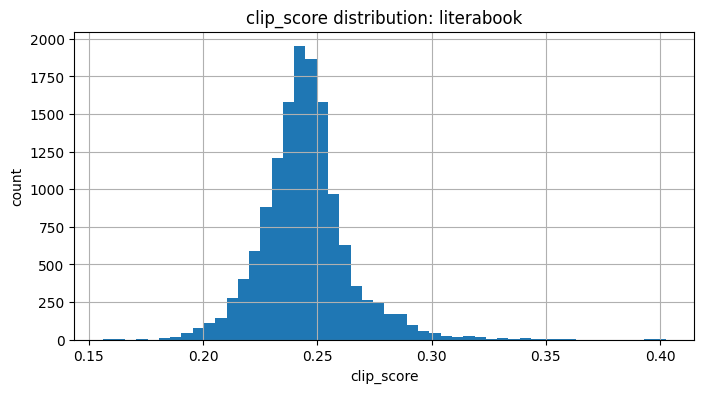

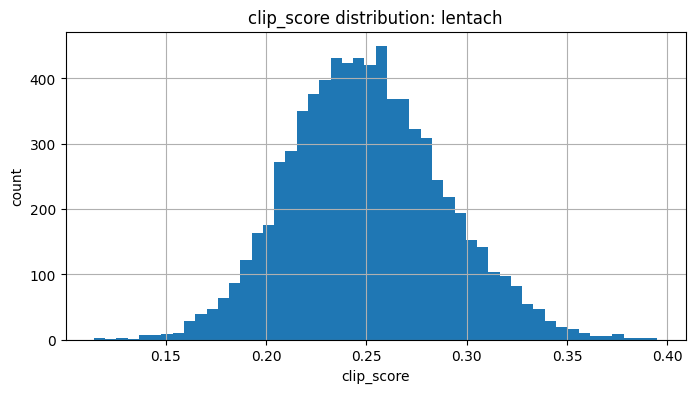

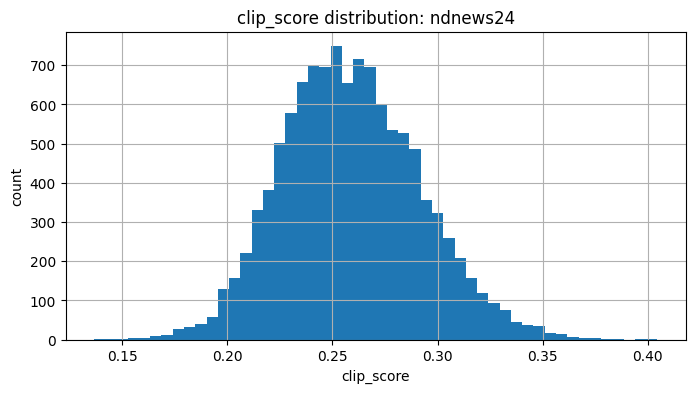

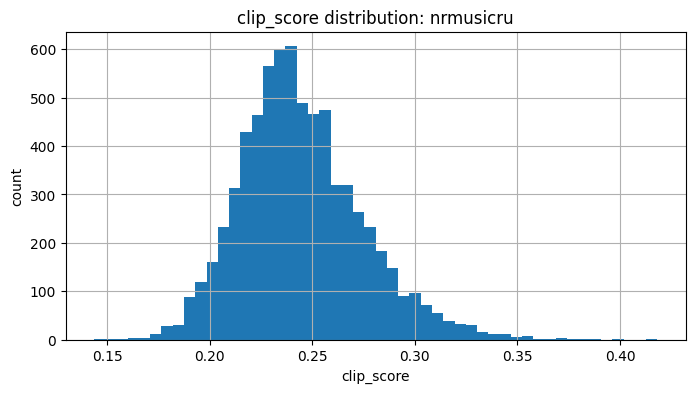

In [92]:
import matplotlib.pyplot as plt

for domain in data["domain"].dropna().unique():
    subset = data.loc[data["domain"] == domain, "clip_score"].dropna()
    
    plt.figure(figsize=(8, 4))
    subset.hist(bins=50)
    plt.title(f"clip_score distribution: {domain}")
    plt.xlabel("clip_score")
    plt.ylabel("count")
    plt.show()

In [93]:
print("Дубликатов post_id:", posts_all["post_id"].duplicated().sum())

Дубликатов post_id: 0


In [94]:
emb_df = data[["post_id", "image_embedding"]].copy()

# превратить numpy array в обычный list
emb_df["image_embedding"] = emb_df["image_embedding"].apply(
    lambda x: x.tolist() if x is not None else None
)

In [97]:
emb_df.to_csv("clip_image_embeddings.csv", index=False)
